<a href="https://colab.research.google.com/github/BeastHunter0041/csci_4170_s26/blob/main/final_project_CSCI4170.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, brier_score_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import BallTree

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

SNAKE_PATH = "/content/Brown Treesnake Visual Survey database_housing area of Andersen Air Force Base__05.08.2024.csv"
TREE_PATH  = "/content/Tree database for brown treesnake surveys_housing area of Andersen Air Force Base__05.08.2024 (1).csv"

# Choose one of these target definitions:
USE_SVL_AS_TARGET = True
LARGE_SNAKE_THRESHOLD = 1200   # example in mm; adjust if needed

# fallback max distance for snakes with missing/invalid Tree Tag Number
MAX_MATCH_DISTANCE_METERS = 20

# for spatial CV blocks
SPATIAL_BLOCK_SIZE_DEG = 0.0015

In [ ]:
snake_df = pd.read_csv(SNAKE_PATH)
tree_df = pd.read_csv(TREE_PATH)

print("Snake shape:", snake_df.shape)
print("Tree shape :", tree_df.shape)

print("\nSnake columns:")
print(snake_df.columns.tolist())

print("\nTree columns:")
print(tree_df.columns.tolist())

Snake shape: (451, 22)
Tree shape : (1240, 10)

Snake columns:
['Date', 'Tree Tag Number', 'Time', 'New', 'PIT Tag', 'Clip', 'SVL', 'Total Length', 'Tailbreak', 'Weight', 'HL', 'HW', 'Palped', 'Probed', 'Sex', 'Bulge', 'Follicles', 'Perch Height', 'Perch Diameter', 'Telemetry Snake', 'Latitude', 'Longitude']

Tree columns:
['Date', 'Tree Genus', 'Tree Tag Number', 'Latitude', 'Longitude', 'Row/Group', 'Small tree', 'Trunk Vegetation present', 'Community Cluster', 'Tree Island']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load raw files ---
snake_path = "Brown Treesnake Visual Survey database_housing area of Andersen Air Force Base__05.08.2024.csv"
tree_path  = "Tree database for brown treesnake surveys_housing area of Andersen Air Force Base__05.08.2024 (1).csv"

snake_raw = pd.read_csv(snake_path)
tree_raw  = pd.read_csv(tree_path)

# --- Make copies ---
snake = snake_raw.copy()
tree  = tree_raw.copy()

# --- Force coordinates numeric ---
for df in [snake, tree]:
    df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")
    df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")

# --- Inspect obviously bad rows first ---
print("Potential snake outliers:")
display(
    snake.loc[
        (snake["Latitude"] < 13.54) | (snake["Latitude"] > 13.58) |
        (snake["Longitude"] < 144.90) | (snake["Longitude"] > 144.94),
        ["Date", "Tree Tag Number", "Latitude", "Longitude"]
    ].sort_values(["Latitude", "Longitude"])
)

print("Potential tree outliers:")
display(
    tree.loc[
        (tree["Latitude"] < 13.54) | (tree["Latitude"] > 13.58) |
        (tree["Longitude"] < 144.90) | (tree["Longitude"] > 144.94),
        ["Date", "Tree Tag Number", "Tree Genus", "Latitude", "Longitude"]
    ].sort_values(["Latitude", "Longitude"])
)

Potential snake outliers:


,Date,Tree Tag Number,Latitude,Longitude
402,6/9/2022,155,13.532856,142.637658


Potential tree outliers:


,Date,Tree Tag Number,Tree Genus,Latitude,Longitude
59,12/24/2019,1247,CALOPHYLLUM,22.588357,144.815652


In [ ]:
# --- Andersen-area bounding box ---
LAT_MIN, LAT_MAX = 13.54, 13.58
LON_MIN, LON_MAX = 144.90, 144.94

snake_clean = snake[
    snake["Latitude"].between(LAT_MIN, LAT_MAX) &
    snake["Longitude"].between(LON_MIN, LON_MAX)
].copy()

tree_clean = tree[
    tree["Latitude"].between(LAT_MIN, LAT_MAX) &
    tree["Longitude"].between(LON_MIN, LON_MAX)
].copy()

print("Snake rows before/after:", len(snake), "->", len(snake_clean))
print("Tree rows before/after :", len(tree),  "->", len(tree_clean))

Snake rows before/after: 451 -> 450
Tree rows before/after : 1240 -> 1239


In [ ]:
removed_snake = snake.loc[~snake.index.isin(snake_clean.index),
                          ["Date", "Tree Tag Number", "Latitude", "Longitude"]]

removed_tree = tree.loc[~tree.index.isin(tree_clean.index),
                        ["Date", "Tree Tag Number", "Tree Genus", "Latitude", "Longitude"]]

print("Removed snake rows:")
display(removed_snake)

print("Removed tree rows:")
display(removed_tree)

Removed snake rows:


,Date,Tree Tag Number,Latitude,Longitude
402,6/9/2022,155,13.532856,142.637658


Removed tree rows:


,Date,Tree Tag Number,Tree Genus,Latitude,Longitude
59,12/24/2019,1247,CALOPHYLLUM,22.588357,144.815652


In [ ]:
snake_clean.to_csv("snake_clean.csv", index=False)
tree_clean.to_csv("tree_clean.csv", index=False)

In [ ]:
# Standardize Tree Tag Number as string for safer joining
snake_df["Tree Tag Number"] = snake_df["Tree Tag Number"].astype(str).str.strip()
tree_df["Tree Tag Number"] = tree_df["Tree Tag Number"].astype(str).str.strip()

# Clean numeric columns in snake data
snake_numeric_cols = ["SVL", "Total Length", "Weight", "HL", "HW",
                      "Perch Height", "Perch Diameter", "Latitude", "Longitude"]
for col in snake_numeric_cols:
    snake_df[col] = pd.to_numeric(snake_df[col], errors="coerce")

# Clean numeric columns in tree data
tree_numeric_cols = ["Latitude", "Longitude"]
for col in tree_numeric_cols:
    tree_df[col] = pd.to_numeric(tree_df[col], errors="coerce")

# Remove rows with missing coordinates
snake_df = snake_df.dropna(subset=["Latitude", "Longitude"]).copy()
tree_df = tree_df.dropna(subset=["Latitude", "Longitude"]).copy()

print("Snake cleaned shape before outlier removal:", snake_df.shape)
print("Tree cleaned shape before outlier removal :", tree_df.shape)

# ------------------------------------------------------------
# Use the filtered versions created in your new outlier block
# ------------------------------------------------------------
snake_df = snake_clean.copy()
tree_df = tree_clean.copy()

print("Snake cleaned shape after outlier removal:", snake_df.shape)
print("Tree cleaned shape after outlier removal :", tree_df.shape)

Snake cleaned shape before outlier removal: (451, 22)
Tree cleaned shape before outlier removal : (1240, 10)
Snake cleaned shape after outlier removal: (450, 22)
Tree cleaned shape after outlier removal : (1239, 10)


##Define the target label: “large snake"

In [ ]:
if USE_SVL_AS_TARGET:
    size_col = "SVL"
else:
    size_col = "Total Length"

# Force size columns to numeric
for col in ["SVL", "Total Length"]:
    if col in snake_df.columns:
        snake_df[col] = pd.to_numeric(snake_df[col], errors="coerce")

# Optional: check how many became missing
print(snake_df[["SVL", "Total Length"]].dtypes)
print("\nMissing values after numeric conversion:")
print(snake_df[["SVL", "Total Length"]].isna().sum())

# Create target
snake_df["is_large_snake"] = (snake_df[size_col] >= LARGE_SNAKE_THRESHOLD).astype(int)

print("\nUsing size column:", size_col)
print("Threshold:", LARGE_SNAKE_THRESHOLD)
print(snake_df["is_large_snake"].value_counts())

SVL             float64
Total Length    float64
dtype: object

Missing values after numeric conversion:
SVL             2
Total Length    2
dtype: int64

Using size column: SVL
Threshold: 1200
is_large_snake
0    390
1     60
Name: count, dtype: int64


In [ ]:
snake_df["Tree Tag Number"] = snake_df["Tree Tag Number"].astype(str).str.strip()
tree_df["Tree Tag Number"] = tree_df["Tree Tag Number"].astype(str).str.strip()

##Match snakes to trees

This version joins on Tree Tag Number if the tag is valid and exists in the tree file
for rows like NoData, do nearest-tree spatial fallback

In [ ]:
def haversine_rad(df, lat_col="Latitude", lon_col="Longitude"):
    return np.deg2rad(df[[lat_col, lon_col]].values)

def attach_snakes_to_trees(snake_df, tree_df, max_match_distance_m=20):
    snake = snake_df.copy()
    tree = tree_df.copy()

    # --- make merge keys consistent ---
    snake["Tree Tag Number"] = snake["Tree Tag Number"].astype(str).str.strip()
    tree["Tree Tag Number"] = tree["Tree Tag Number"].astype(str).str.strip()

    # also make sure coordinates are numeric
    for df in [snake, tree]:
        df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")
        df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")

    snake = snake.dropna(subset=["Latitude", "Longitude"]).copy()
    tree = tree.dropna(subset=["Latitude", "Longitude"]).copy()

    # Build lookup of valid tree tags
    valid_tree_tags = set(tree["Tree Tag Number"])

    # Split snake records into direct-tag matches vs fallback spatial matches
    snake["has_valid_tree_tag"] = snake["Tree Tag Number"].isin(valid_tree_tags)

    direct = snake[snake["has_valid_tree_tag"]].copy()
    fallback = snake[~snake["has_valid_tree_tag"]].copy()

    # ---- Direct join on Tree Tag Number ----
    direct_merged = direct.merge(
        tree.add_prefix("tree_"),
        left_on="Tree Tag Number",
        right_on="tree_Tree Tag Number",
        how="left"
    )
    direct_merged["match_type"] = "tree_tag"
    direct_merged["match_distance_m"] = np.nan

    # ---- Fallback nearest-neighbor spatial match ----
    if len(fallback) > 0:
        tree_rad = haversine_rad(tree, "Latitude", "Longitude")
        fallback_rad = haversine_rad(fallback, "Latitude", "Longitude")

        bt = BallTree(tree_rad, metric="haversine")
        dist_rad, idx = bt.query(fallback_rad, k=1)

        earth_radius_m = 6371000
        dist_m = dist_rad.flatten() * earth_radius_m
        idx = idx.flatten()

        fallback = fallback.reset_index(drop=True)
        fallback["matched_tree_index"] = idx
        fallback["match_distance_m"] = dist_m

        fallback = fallback[fallback["match_distance_m"] <= max_match_distance_m].copy()

        matched_tree = tree.iloc[fallback["matched_tree_index"].values].reset_index(drop=True)
        matched_tree = matched_tree.add_prefix("tree_")

        fallback_merged = pd.concat([fallback.reset_index(drop=True), matched_tree], axis=1)
        fallback_merged["match_type"] = "spatial"

        merged = pd.concat([direct_merged, fallback_merged], ignore_index=True)
    else:
        merged = direct_merged.copy()

    return merged

merged_obs = attach_snakes_to_trees(
    snake_df, tree_df, max_match_distance_m=MAX_MATCH_DISTANCE_METERS
)

print("Merged observation-level shape:", merged_obs.shape)
print(merged_obs["match_type"].value_counts(dropna=False))
print(merged_obs[["match_distance_m"]].describe())

Merged observation-level shape: (429, 37)
match_type
tree_tag    402
spatial      27
Name: count, dtype: int64
       match_distance_m
count         27.000000
mean           6.827255
std            7.407972
min            0.000000
25%            0.000000
50%            5.002775
75%           13.935939
max           19.976339


##Build the tree-level dataset

Each row becomes one tree, with features from the tree table and labels/aggregates derived from snake observations.

In [ ]:
# Make sure columns used in aggregation are numeric
agg_numeric_cols = [size_col, "Weight", "Perch Height", "Perch Diameter"]
for col in agg_numeric_cols:
    if col in merged_obs.columns:
        merged_obs[col] = pd.to_numeric(merged_obs[col], errors="coerce")

# Optional sanity check
print(merged_obs[agg_numeric_cols].dtypes)
print("\nMissing values after numeric conversion:")
print(merged_obs[agg_numeric_cols].isna().sum())

agg_dict = {
    "is_large_snake": "max",
    size_col: ["max", "mean", "count"],
    "Weight": ["max", "mean"],
    "Perch Height": ["max", "mean"],
    "Perch Diameter": ["max", "mean"],
}

tree_level_snake = merged_obs.groupby("tree_Tree Tag Number").agg(agg_dict)
tree_level_snake.columns = [
    "_".join([str(x) for x in col if x != ""]).strip("_")
    for col in tree_level_snake.columns
]
tree_level_snake = tree_level_snake.reset_index()

tree_level_snake = tree_level_snake.rename(columns={
    "tree_Tree Tag Number": "Tree Tag Number",
    "is_large_snake_max": "target_large_snake_tree"
})

# Make sure merge keys match types
tree_df["Tree Tag Number"] = tree_df["Tree Tag Number"].astype(str).str.strip()
tree_level_snake["Tree Tag Number"] = tree_level_snake["Tree Tag Number"].astype(str).str.strip()

model_df = tree_df.merge(tree_level_snake, on="Tree Tag Number", how="left")

# Trees with no snake observation become negatives for now
model_df["target_large_snake_tree"] = model_df["target_large_snake_tree"].fillna(0).astype(int)

# Number of snake observations on that tree
count_col = f"{size_col}_count"
if count_col in model_df.columns:
    model_df["n_snake_obs"] = model_df[count_col].fillna(0)
else:
    model_df["n_snake_obs"] = 0

print("Final tree-level shape:", model_df.shape)
print(model_df["target_large_snake_tree"].value_counts())
print(model_df.head())

SVL               float64
Weight            float64
Perch Height      float64
Perch Diameter    float64
dtype: object

Missing values after numeric conversion:
SVL                2
Weight             3
Perch Height       1
Perch Diameter    25
dtype: int64
Final tree-level shape: (1239, 21)
target_large_snake_tree
0    1186
1      53
Name: count, dtype: int64
         Date Tree Genus Tree Tag Number   Latitude   Longitude Row/Group  \
0  12/27/2019    ALBIZIA            1811  13.561757  144.921148         N   
1  12/27/2019    ALBIZIA            1812  13.560963  144.923455         N   
2  12/27/2019    ALBIZIA            1802  13.563675  144.923551         N   
3  12/27/2019    ALBIZIA            1810  13.561075  144.923833         N   
4  12/27/2019    ALBIZIA            1807  13.563692  144.924484         N   

  Small tree Trunk Vegetation present Community Cluster Tree Island  ...  \
0          N                        N                 N           N  ...   
1          N           

# EDA and Feature Engineering

Positive rate: 0.042776432606941084


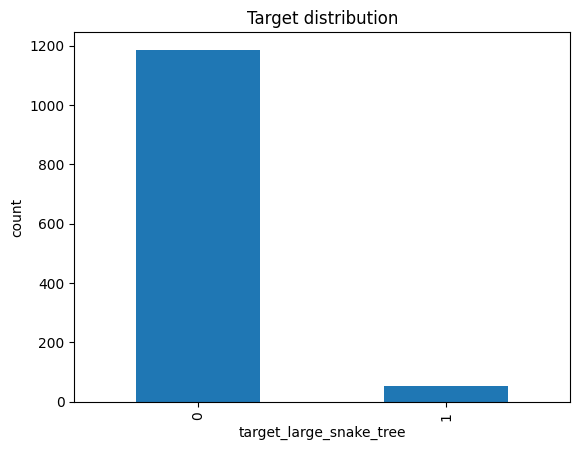

In [ ]:
print("Positive rate:", model_df["target_large_snake_tree"].mean())

model_df["target_large_snake_tree"].value_counts().plot(kind="bar")
plt.title("Target distribution")
plt.xlabel("target_large_snake_tree")
plt.ylabel("count")
plt.show()

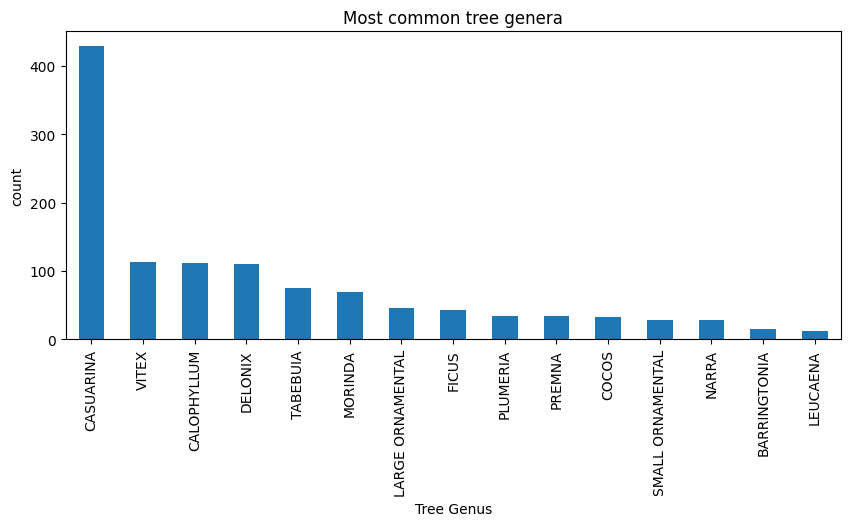

In [ ]:
model_df["Tree Genus"].value_counts().head(15).plot(kind="bar", figsize=(10,4))
plt.title("Most common tree genera")
plt.ylabel("count")
plt.show()

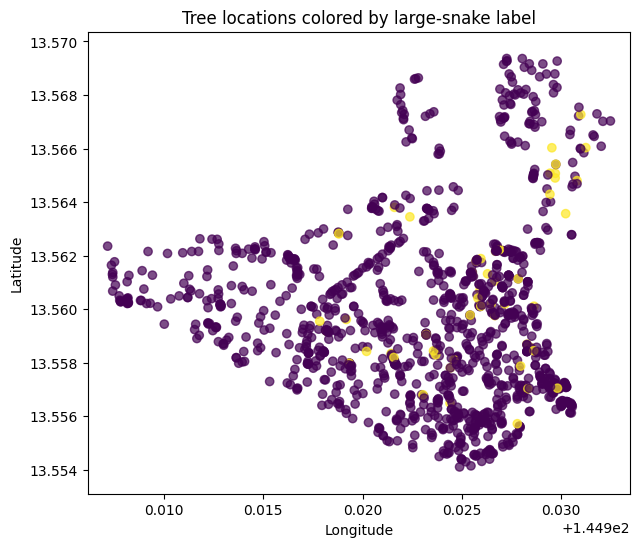

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(
    model_df["Longitude"],
    model_df["Latitude"],
    c=model_df["target_large_snake_tree"],
    alpha=0.7
)
plt.title("Tree locations colored by large-snake label")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Optional but helpful for stable display
plt.xlim(model_df["Longitude"].min() - 0.001, model_df["Longitude"].max() + 0.001)
plt.ylim(model_df["Latitude"].min() - 0.001, model_df["Latitude"].max() + 0.001)

plt.show()

In [ ]:
genus_summary = (
    model_df.groupby("Tree Genus")["target_large_snake_tree"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

print(genus_summary.head(15))

                  count      mean
Tree Genus                       
HERNANDIA             2  0.500000
FICUS                43  0.139535
COCOS                33  0.121212
CASUARINA           429  0.062937
PREMNA               34  0.058824
DELONIX             110  0.045455
NARRA                28  0.035714
SMALL ORNAMENTAL     29  0.034483
PLUMERIA             34  0.029412
CALOPHYLLUM         112  0.026786
MORINDA              70  0.014286
VITEX               114  0.008772
ALBIZIA              11  0.000000
BARRINGTONIA         15  0.000000
INSTIA                2  0.000000


In [ ]:
# Binary Y/N columns
yn_cols = ["Small tree", "Trunk Vegetation present", "Community Cluster", "Tree Island"]
for col in yn_cols:
    model_df[col] = model_df[col].astype(str).str.upper().map({"Y": 1, "N": 0})

# Date feature
model_df["Date"] = pd.to_datetime(model_df["Date"], errors="coerce")
model_df["survey_year"] = model_df["Date"].dt.year

# Spatial blocks for grouped CV
lat0 = model_df["Latitude"].min()
lon0 = model_df["Longitude"].min()

model_df["spatial_block"] = (
    np.floor((model_df["Latitude"] - lat0) / SPATIAL_BLOCK_SIZE_DEG).astype(int).astype(str)
    + "_"
    + np.floor((model_df["Longitude"] - lon0) / SPATIAL_BLOCK_SIZE_DEG).astype(int).astype(str)
)

print(model_df[["Tree Tag Number", "Tree Genus", "Latitude", "Longitude",
                "Small tree", "Trunk Vegetation present",
                "Community Cluster", "Tree Island",
                "survey_year", "spatial_block",
                "target_large_snake_tree"]].head())

  Tree Tag Number Tree Genus   Latitude   Longitude  Small tree  \
0            1811    ALBIZIA  13.561757  144.921148         0.0   
1            1812    ALBIZIA  13.560963  144.923455         0.0   
2            1802    ALBIZIA  13.563675  144.923551         0.0   
3            1810    ALBIZIA  13.561075  144.923833         0.0   
4            1807    ALBIZIA  13.563692  144.924484         0.0   

   Trunk Vegetation present  Community Cluster  Tree Island  survey_year  \
0                       0.0                0.0          0.0         2019   
1                       0.0                0.0          0.0         2019   
2                       0.0                0.0          0.0         2019   
3                       0.0                0.0          0.0         2019   
4                       0.0                0.0          0.0         2019   

  spatial_block  target_large_snake_tree  
0           5_9                        0  
1          4_10                        0  
2          

In [ ]:
feature_cols = [
    "Tree Genus",
    "Latitude",
    "Longitude",
    "Small tree",
    "Trunk Vegetation present",
    "Community Cluster",
    "Tree Island"
]

X = model_df[feature_cols].copy()
y = model_df["target_large_snake_tree"].copy()
groups = model_df["spatial_block"].copy()

categorical_features = ["Tree Genus"]
numeric_features = ["Latitude", "Longitude", "Small tree",
                    "Trunk Vegetation present", "Community Cluster", "Tree Island"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

# Baseline Models

##Logistic Regression

In [ ]:
log_reg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

log_probs = cross_val_predict(
    log_reg, X, y, cv=cv, method="predict_proba"
)[:, 1]

print("Logistic Regression")
print("ROC-AUC :", roc_auc_score(y, log_probs))
print("PR-AUC  :", average_precision_score(y, log_probs))
print("Brier   :", brier_score_loss(y, log_probs))

Logistic Regression
ROC-AUC : 0.6970154952432467
PR-AUC  : 0.10047885455780199
Brier   : 0.19285592460350492


##Random Forest

In [ ]:
rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

rf_probs = cross_val_predict(
    rf, X, y, cv=cv, method="predict_proba"
)[:, 1]

print("Random Forest")
print("ROC-AUC :", roc_auc_score(y, rf_probs))
print("PR-AUC  :", average_precision_score(y, rf_probs))
print("Brier   :", brier_score_loss(y, rf_probs))

Random Forest
ROC-AUC : 0.7035460880078909
PR-AUC  : 0.09206911605966962
Brier   : 0.07567259972452851


#Spatially Aware Validation

In [ ]:
gkf = GroupKFold(n_splits=5)

log_probs_spatial = cross_val_predict(
    log_reg, X, y, cv=gkf.split(X, y, groups=groups), method="predict_proba"
)[:, 1]

rf_probs_spatial = cross_val_predict(
    rf, X, y, cv=gkf.split(X, y, groups=groups), method="predict_proba"
)[:, 1]

print("Spatial CV - Logistic Regression")
print("ROC-AUC :", roc_auc_score(y, log_probs_spatial))
print("PR-AUC  :", average_precision_score(y, log_probs_spatial))
print("Brier   :", brier_score_loss(y, log_probs_spatial))

print("\nSpatial CV - Random Forest")
print("ROC-AUC :", roc_auc_score(y, rf_probs_spatial))
print("PR-AUC  :", average_precision_score(y, rf_probs_spatial))
print("Brier   :", brier_score_loss(y, rf_probs_spatial))

Spatial CV - Logistic Regression
ROC-AUC : 0.6912883006140825
PR-AUC  : 0.08992332893815015
Brier   : 0.19437978687186913

Spatial CV - Random Forest
ROC-AUC : 0.7029097330490948
PR-AUC  : 0.09866011339722074
Brier   : 0.07380738908039867


In [ ]:
def precision_at_k(y_true, y_score, k=50):
    order = np.argsort(-np.array(y_score))
    topk = np.array(y_true)[order[:k]]
    return topk.mean()

for k in [25, 50, 100]:
    print(f"LogReg Precision@{k}: {precision_at_k(y, log_probs_spatial, k):.4f}")
    print(f"RF     Precision@{k}: {precision_at_k(y, rf_probs_spatial, k):.4f}")

LogReg Precision@25: 0.0800
RF     Precision@25: 0.1600
LogReg Precision@50: 0.1000
RF     Precision@50: 0.1600
LogReg Precision@100: 0.1200
RF     Precision@100: 0.1200


#PyTorch Spatial Embedding Model

In [ ]:
# Non-spatial structured features for the neural net
nn_cat_cols = ["Tree Genus"]
nn_num_cols = ["Small tree", "Trunk Vegetation present", "Community Cluster", "Tree Island"]

nn_df = model_df.copy()

# Fill categorical
for c in nn_cat_cols:
    nn_df[c] = nn_df[c].fillna("Unknown").astype(str)

# Fill numeric
for c in nn_num_cols + ["Latitude", "Longitude"]:
    nn_df[c] = pd.to_numeric(nn_df[c], errors="coerce")
    nn_df[c] = nn_df[c].fillna(nn_df[c].median())

# Encode genus manually
genus_to_idx = {g: i for i, g in enumerate(sorted(nn_df["Tree Genus"].unique()))}
nn_df["genus_idx"] = nn_df["Tree Genus"].map(genus_to_idx).astype(int)

# Standardize numeric features
for c in nn_num_cols + ["Latitude", "Longitude"]:
    mean = nn_df[c].mean()
    std = nn_df[c].std()
    if std == 0:
        std = 1.0
    nn_df[c] = (nn_df[c] - mean) / std

y_nn = nn_df["target_large_snake_tree"].values.astype(np.float32)
groups_nn = nn_df["spatial_block"].values

In [ ]:
class TreeDataset(Dataset):
    def __init__(self, df, target_col="target_large_snake_tree"):
        self.latlon = df[["Latitude", "Longitude"]].values.astype(np.float32)
        self.num = df[["Small tree", "Trunk Vegetation present",
                       "Community Cluster", "Tree Island"]].values.astype(np.float32)
        self.genus = df["genus_idx"].values.astype(np.int64)
        self.y = df[target_col].values.astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.latlon[idx]),
            torch.tensor(self.num[idx]),
            torch.tensor(self.genus[idx]),
            torch.tensor(self.y[idx])
        )

In [ ]:
class SpatialRiskNet(nn.Module):
    def __init__(self, num_genus, genus_emb_dim=8, spatial_hidden=16, num_hidden=16):
        super().__init__()

        self.genus_emb = nn.Embedding(num_genus, genus_emb_dim)

        # Lat/lon -> learned spatial embedding
        self.spatial_net = nn.Sequential(
            nn.Linear(2, spatial_hidden),
            nn.ReLU(),
            nn.Linear(spatial_hidden, spatial_hidden),
            nn.ReLU()
        )

        # other numeric tree features
        self.num_net = nn.Sequential(
            nn.Linear(4, num_hidden),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Linear(spatial_hidden + num_hidden + genus_emb_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, latlon, num_feats, genus_idx):
        spatial = self.spatial_net(latlon)
        num_part = self.num_net(num_feats)
        genus_part = self.genus_emb(genus_idx)

        x = torch.cat([spatial, num_part, genus_part], dim=1)
        logits = self.head(x).squeeze(1)
        return logits

In [ ]:
unique_blocks = pd.Series(groups_nn).unique()
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(unique_blocks)

split_idx = int(0.8 * len(unique_blocks))
train_blocks = set(unique_blocks[:split_idx])
val_blocks = set(unique_blocks[split_idx:])

train_mask = nn_df["spatial_block"].isin(train_blocks)
val_mask = nn_df["spatial_block"].isin(val_blocks)

train_df = nn_df[train_mask].copy()
val_df = nn_df[val_mask].copy()

print("Train size:", len(train_df))
print("Val size  :", len(val_df))
print("Train positive rate:", train_df["target_large_snake_tree"].mean())
print("Val positive rate  :", val_df["target_large_snake_tree"].mean())

Train size: 1019
Val size  : 220
Train positive rate: 0.04416094210009813
Val positive rate  : 0.03636363636363636


In [ ]:
train_ds = TreeDataset(train_df)
val_ds = TreeDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = SpatialRiskNet(num_genus=len(genus_to_idx)).to(device)

# Handle class imbalance
pos_rate = train_df["target_large_snake_tree"].mean()
pos_weight = (1 - pos_rate) / max(pos_rate, 1e-6)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def evaluate_model(model, loader):
    model.eval()
    all_probs, all_y = [], []

    with torch.no_grad():
        for latlon, num_feats, genus_idx, yb in loader:
            latlon = latlon.to(device)
            num_feats = num_feats.to(device)
            genus_idx = genus_idx.to(device)
            yb = yb.to(device)

            logits = model(latlon, num_feats, genus_idx)
            probs = torch.sigmoid(logits)

            all_probs.extend(probs.cpu().numpy())
            all_y.extend(yb.cpu().numpy())

    all_probs = np.array(all_probs)
    all_y = np.array(all_y)

    roc = roc_auc_score(all_y, all_probs) if len(np.unique(all_y)) > 1 else np.nan
    pr = average_precision_score(all_y, all_probs) if len(np.unique(all_y)) > 1 else np.nan
    brier = brier_score_loss(all_y, all_probs)

    return roc, pr, brier, all_y, all_probs

best_val_pr = -np.inf
best_state = None

for epoch in range(1, 31):
    model.train()
    running_loss = 0.0

    for latlon, num_feats, genus_idx, yb in train_loader:
        latlon = latlon.to(device)
        num_feats = num_feats.to(device)
        genus_idx = genus_idx.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(latlon, num_feats, genus_idx)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(yb)

    train_loss = running_loss / len(train_ds)
    val_roc, val_pr, val_brier, _, _ = evaluate_model(model, val_loader)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_roc={val_roc:.4f} | val_pr={val_pr:.4f} | val_brier={val_brier:.4f}")

    if val_pr > best_val_pr:
        best_val_pr = val_pr
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)

val_roc, val_pr, val_brier, val_y, val_probs = evaluate_model(model, val_loader)
print("\nBest NN validation results")
print("ROC-AUC :", val_roc)
print("PR-AUC  :", val_pr)
print("Brier   :", val_brier)

Device: cuda
Epoch 01 | train_loss=1.3128 | val_roc=0.7506 | val_pr=0.1449 | val_brier=0.2316
Epoch 02 | train_loss=1.2642 | val_roc=0.7388 | val_pr=0.1704 | val_brier=0.2358
Epoch 03 | train_loss=1.2471 | val_roc=0.7347 | val_pr=0.1704 | val_brier=0.2372
Epoch 04 | train_loss=1.2054 | val_roc=0.7453 | val_pr=0.1921 | val_brier=0.2342
Epoch 05 | train_loss=1.1887 | val_roc=0.7535 | val_pr=0.1957 | val_brier=0.2205
Epoch 06 | train_loss=1.1393 | val_roc=0.7577 | val_pr=0.2070 | val_brier=0.2009
Epoch 07 | train_loss=1.1199 | val_roc=0.7653 | val_pr=0.2025 | val_brier=0.1916
Epoch 08 | train_loss=1.0884 | val_roc=0.7742 | val_pr=0.2004 | val_brier=0.1709
Epoch 09 | train_loss=1.0647 | val_roc=0.7677 | val_pr=0.1986 | val_brier=0.1765
Epoch 10 | train_loss=1.0292 | val_roc=0.7659 | val_pr=0.1981 | val_brier=0.1636
Epoch 11 | train_loss=0.9968 | val_roc=0.7647 | val_pr=0.1968 | val_brier=0.1553
Epoch 12 | train_loss=0.9803 | val_roc=0.7630 | val_pr=0.2594 | val_brier=0.1549
Epoch 13 | trai

In [ ]:
model.eval()

full_ds = TreeDataset(nn_df)
full_loader = DataLoader(full_ds, batch_size=256, shuffle=False)

all_probs = []
with torch.no_grad():
    for latlon, num_feats, genus_idx, yb in full_loader:
        latlon = latlon.to(device)
        num_feats = num_feats.to(device)
        genus_idx = genus_idx.to(device)

        probs = torch.sigmoid(model(latlon, num_feats, genus_idx))
        all_probs.extend(probs.cpu().numpy())

model_df["nn_risk_score"] = np.array(all_probs)

risk_ranked = model_df.sort_values("nn_risk_score", ascending=False)[[
    "Tree Tag Number", "Tree Genus", "Latitude", "Longitude",
    "Small tree", "Trunk Vegetation present", "Community Cluster", "Tree Island",
    "target_large_snake_tree", "nn_risk_score"
]]

print(risk_ranked.head(20))

    Tree Tag Number Tree Genus   Latitude   Longitude  Small tree  \
492             432  CASUARINA  13.565987  144.930977         0.0   
390             166  CASUARINA  13.561987  144.928065         0.0   
389             167  CASUARINA  13.561968  144.928046         0.0   
387             157  CASUARINA  13.562192  144.926714         0.0   
386             158  CASUARINA  13.562165  144.926696         0.0   
388             168  CASUARINA  13.561267  144.927350         0.0   
382             177  CASUARINA  13.560469  144.925999         0.0   
383             186  CASUARINA  13.559877  144.926559         0.0   
381             134  CASUARINA  13.560430  144.924485         0.0   
490             345  CASUARINA  13.568038  144.927624         0.0   
384             189  CASUARINA  13.559788  144.926643         0.0   
385             188  CASUARINA  13.559761  144.926652         0.0   
556             380  CASUARINA  13.562392  144.921447         0.0   
733            1714      FICUS  13

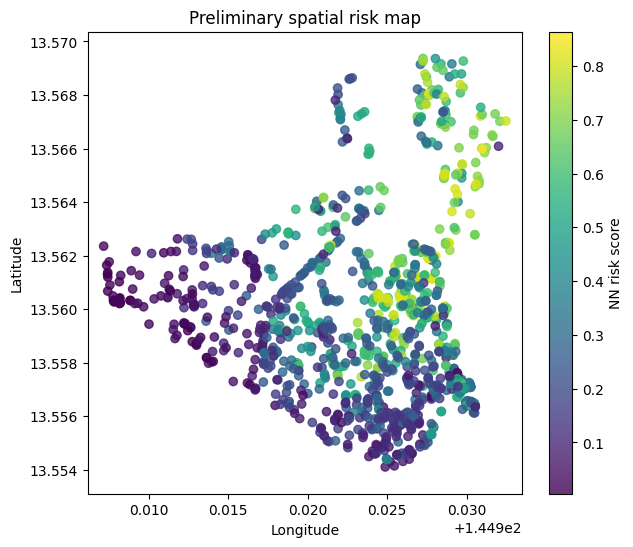

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(
    model_df["Longitude"],
    model_df["Latitude"],
    c=model_df["nn_risk_score"],
    alpha=0.8
)
plt.colorbar(label="NN risk score")
plt.title("Preliminary spatial risk map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.xlim(model_df["Longitude"].min() - 0.001, model_df["Longitude"].max() + 0.001)
plt.ylim(model_df["Latitude"].min() - 0.001, model_df["Latitude"].max() + 0.001)

plt.show()

In [ ]:
import copy
from sklearn.calibration import calibration_curve

N_SPLITS = 5
NN_EPOCHS = 40
NN_PATIENCE = 8
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


##Modeling Dataframe for remaining experiements

In [ ]:
TARGET_COL = "target_large_snake_tree"
GROUP_COL = "spatial_block"
CAT_COL = "Tree Genus"
SPATIAL_COLS = ["Latitude", "Longitude"]
NUM_COLS = ["Small tree", "Trunk Vegetation present", "Community Cluster", "Tree Island"]

proj_df = model_df.copy()

# Clean categorical
proj_df[CAT_COL] = proj_df[CAT_COL].fillna("Unknown").astype(str).str.strip()

# Clean numeric
for c in SPATIAL_COLS + NUM_COLS:
    proj_df[c] = pd.to_numeric(proj_df[c], errors="coerce")

for c in SPATIAL_COLS + NUM_COLS:
    proj_df[c] = proj_df[c].fillna(proj_df[c].median())

proj_df[TARGET_COL] = pd.to_numeric(proj_df[TARGET_COL], errors="coerce").fillna(0).astype(int)
proj_df[GROUP_COL] = proj_df[GROUP_COL].astype(str)

# Global genus encoding
all_genera = sorted(proj_df[CAT_COL].unique())
genus_to_idx = {g: i for i, g in enumerate(all_genera)}
proj_df["genus_idx"] = proj_df[CAT_COL].map(genus_to_idx).astype(int)

print(proj_df[[CAT_COL, "genus_idx"] + SPATIAL_COLS + NUM_COLS + [TARGET_COL, GROUP_COL]].head())
print("\nTarget counts:")
print(proj_df[TARGET_COL].value_counts())
print("\nNumber of spatial blocks:", proj_df[GROUP_COL].nunique())

  Tree Genus  genus_idx   Latitude   Longitude  Small tree  \
0    ALBIZIA          0  13.561757  144.921148         0.0   
1    ALBIZIA          0  13.560963  144.923455         0.0   
2    ALBIZIA          0  13.563675  144.923551         0.0   
3    ALBIZIA          0  13.561075  144.923833         0.0   
4    ALBIZIA          0  13.563692  144.924484         0.0   

   Trunk Vegetation present  Community Cluster  Tree Island  \
0                       0.0                0.0          0.0   
1                       0.0                0.0          0.0   
2                       0.0                0.0          0.0   
3                       0.0                0.0          0.0   
4                       0.0                0.0          0.0   

   target_large_snake_tree spatial_block  
0                        0           5_9  
1                        0          4_10  
2                        0          6_10  
3                        0          4_11  
4                        0       

##Helpers

In [ ]:
def safe_standardize(train_arr, val_arr):
    mean = np.nanmean(train_arr, axis=0)
    std = np.nanstd(train_arr, axis=0)
    std[std == 0] = 1.0
    return (train_arr - mean) / std, (val_arr - mean) / std, mean, std

def precision_at_k(y_true, y_score, k):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(-y_score)
    topk = y_true[order[:k]]
    return float(topk.mean()) if len(topk) > 0 else np.nan

def recall_at_k(y_true, y_score, k):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    total_pos = y_true.sum()
    if total_pos == 0:
        return np.nan
    order = np.argsort(-y_score)
    topk = y_true[order[:k]]
    return float(topk.sum() / total_pos)

def summarize_predictions(y_true, probs, model_name="model"):
    out = {
        "model": model_name,
        "roc_auc": roc_auc_score(y_true, probs),
        "pr_auc": average_precision_score(y_true, probs),
        "brier": brier_score_loss(y_true, probs),
    }
    for k in [25, 50, 100]:
        out[f"precision@{k}"] = precision_at_k(y_true, probs, k)
        out[f"recall@{k}"] = recall_at_k(y_true, probs, k)
    return out

In [ ]:
class RiskArrayDataset(Dataset):
    def __init__(self, spatial, num_feats, genus_idx, y):
        self.spatial = torch.tensor(spatial, dtype=torch.float32)
        self.num_feats = torch.tensor(num_feats, dtype=torch.float32)
        self.genus_idx = torch.tensor(genus_idx, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.spatial[idx], self.num_feats[idx], self.genus_idx[idx], self.y[idx]


class SpatialRiskNetCV(nn.Module):
    def __init__(self, num_genus, genus_emb_dim=8, spatial_hidden=16, num_hidden=16):
        super().__init__()
        self.genus_emb = nn.Embedding(num_genus, genus_emb_dim)

        self.spatial_net = nn.Sequential(
            nn.Linear(2, spatial_hidden),
            nn.ReLU(),
            nn.Linear(spatial_hidden, spatial_hidden),
            nn.ReLU()
        )

        self.num_net = nn.Sequential(
            nn.Linear(len(NUM_COLS), num_hidden),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Linear(spatial_hidden + num_hidden + genus_emb_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, spatial, num_feats, genus_idx):
        s = self.spatial_net(spatial)
        n = self.num_net(num_feats)
        g = self.genus_emb(genus_idx)
        x = torch.cat([s, n, g], dim=1)
        return self.head(x).squeeze(1)


class NoSpatialRiskNetCV(nn.Module):
    def __init__(self, num_genus, genus_emb_dim=8, num_hidden=16):
        super().__init__()
        self.genus_emb = nn.Embedding(num_genus, genus_emb_dim)

        self.num_net = nn.Sequential(
            nn.Linear(len(NUM_COLS), num_hidden),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Linear(num_hidden + genus_emb_dim, 24),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(24, 1)
        )

    def forward(self, spatial, num_feats, genus_idx):
        n = self.num_net(num_feats)
        g = self.genus_emb(genus_idx)
        x = torch.cat([n, g], dim=1)
        return self.head(x).squeeze(1)

##Training + Fold-Evaluation Functions

In [ ]:
def evaluate_loader(model, loader):
    model.eval()
    probs_all, y_all = [], []

    with torch.no_grad():
        for spatial, num_feats, genus_idx, y in loader:
            spatial = spatial.to(device)
            num_feats = num_feats.to(device)
            genus_idx = genus_idx.to(device)
            y = y.to(device)

            logits = model(spatial, num_feats, genus_idx)
            probs = torch.sigmoid(logits)

            probs_all.extend(probs.cpu().numpy())
            y_all.extend(y.cpu().numpy())

    probs_all = np.array(probs_all)
    y_all = np.array(y_all)

    roc = roc_auc_score(y_all, probs_all) if len(np.unique(y_all)) > 1 else np.nan
    pr = average_precision_score(y_all, probs_all) if len(np.unique(y_all)) > 1 else np.nan
    brier = brier_score_loss(y_all, probs_all)

    return roc, pr, brier, y_all, probs_all


def train_one_fold(model, train_loader, val_loader, pos_weight, epochs=NN_EPOCHS, patience=NN_PATIENCE):
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=device))
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_state = None
    best_val_pr = -np.inf
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for spatial, num_feats, genus_idx, y in train_loader:
            spatial = spatial.to(device)
            num_feats = num_feats.to(device)
            genus_idx = genus_idx.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(spatial, num_feats, genus_idx)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(y)

        train_loss = running_loss / len(train_loader.dataset)
        val_roc, val_pr, val_brier, _, _ = evaluate_loader(model, val_loader)

        if val_pr > best_val_pr:
            best_val_pr = val_pr
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

##GroupKFold spatial CV for the neural net and the ablation

In [ ]:
def run_nn_group_cv(df, model_type="spatial", n_splits=N_SPLITS):
    gkf = GroupKFold(n_splits=n_splits)

    y_true = df[TARGET_COL].values.astype(np.float32)
    groups = df[GROUP_COL].values
    oof_probs = np.zeros(len(df), dtype=np.float32)
    fold_rows = []

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(df, y_true, groups=groups), start=1):
        train_df = df.iloc[tr_idx].copy()
        val_df = df.iloc[va_idx].copy()

        # arrays
        Xs_tr = train_df[SPATIAL_COLS].values.astype(np.float32)
        Xs_va = val_df[SPATIAL_COLS].values.astype(np.float32)

        Xn_tr = train_df[NUM_COLS].values.astype(np.float32)
        Xn_va = val_df[NUM_COLS].values.astype(np.float32)

        Xg_tr = train_df["genus_idx"].values.astype(np.int64)
        Xg_va = val_df["genus_idx"].values.astype(np.int64)

        y_tr = train_df[TARGET_COL].values.astype(np.float32)
        y_va = val_df[TARGET_COL].values.astype(np.float32)

        # standardize within fold using training data only
        Xs_tr, Xs_va, _, _ = safe_standardize(Xs_tr, Xs_va)
        Xn_tr, Xn_va, _, _ = safe_standardize(Xn_tr, Xn_va)

        train_ds = RiskArrayDataset(Xs_tr, Xn_tr, Xg_tr, y_tr)
        val_ds = RiskArrayDataset(Xs_va, Xn_va, Xg_va, y_va)

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

        pos_rate = y_tr.mean()
        pos_weight = (1 - pos_rate) / max(pos_rate, 1e-6)

        if model_type == "spatial":
            model = SpatialRiskNetCV(num_genus=len(genus_to_idx)).to(device)
        elif model_type == "no_spatial":
            model = NoSpatialRiskNetCV(num_genus=len(genus_to_idx)).to(device)
        else:
            raise ValueError("model_type must be 'spatial' or 'no_spatial'")

        model = train_one_fold(model, train_loader, val_loader, pos_weight=pos_weight)

        fold_roc, fold_pr, fold_brier, y_fold, p_fold = evaluate_loader(model, val_loader)
        oof_probs[va_idx] = p_fold

        fold_rows.append({
            "fold": fold,
            "model_type": model_type,
            "val_roc_auc": fold_roc,
            "val_pr_auc": fold_pr,
            "val_brier": fold_brier,
            "val_positive_rate": float(y_va.mean()),
            "n_val": len(y_va)
        })

        print(f"Fold {fold} | {model_type} | ROC-AUC={fold_roc:.4f} | PR-AUC={fold_pr:.4f} | Brier={fold_brier:.4f}")

    fold_df = pd.DataFrame(fold_rows)
    summary = summarize_predictions(y_true, oof_probs, model_name=model_type)
    return oof_probs, fold_df, summary

In [ ]:
nn_spatial_oof, nn_spatial_folds, nn_spatial_summary = run_nn_group_cv(proj_df, model_type="spatial")
nn_nospatial_oof, nn_nospatial_folds, nn_nospatial_summary = run_nn_group_cv(proj_df, model_type="no_spatial")

print("\nSpatial NN summary:")
print(nn_spatial_summary)

print("\nNo-spatial NN summary:")
print(nn_nospatial_summary)

Fold 1 | spatial | ROC-AUC=0.7773 | PR-AUC=0.2113 | Brier=0.1882
Fold 2 | spatial | ROC-AUC=0.6680 | PR-AUC=0.1895 | Brier=0.2429
Fold 3 | spatial | ROC-AUC=0.6807 | PR-AUC=0.1147 | Brier=0.1664
Fold 4 | spatial | ROC-AUC=0.8000 | PR-AUC=0.1415 | Brier=0.1739
Fold 5 | spatial | ROC-AUC=0.6092 | PR-AUC=0.1041 | Brier=0.1968
Fold 1 | no_spatial | ROC-AUC=0.7774 | PR-AUC=0.2754 | Brier=0.2436
Fold 2 | no_spatial | ROC-AUC=0.7149 | PR-AUC=0.0709 | Brier=0.2037
Fold 3 | no_spatial | ROC-AUC=0.6385 | PR-AUC=0.0832 | Brier=0.2210
Fold 4 | no_spatial | ROC-AUC=0.7102 | PR-AUC=0.0773 | Brier=0.2091
Fold 5 | no_spatial | ROC-AUC=0.5986 | PR-AUC=0.0769 | Brier=0.2246

Spatial NN summary:
{'model': 'spatial', 'roc_auc': np.float64(0.7194788252887462), 'pr_auc': np.float64(0.12225408621157108), 'brier': np.float64(0.19361534970084482), 'precision@25': 0.20000000298023224, 'recall@25': 0.09433962404727936, 'precision@50': 0.18000000715255737, 'recall@50': 0.16981132328510284, 'precision@100': 0.1199

In [ ]:
proj_df["nn_spatial_oof_prob"] = nn_spatial_oof
proj_df["nn_nospatial_oof_prob"] = nn_nospatial_oof

# choose final model as the one with better PR-AUC
best_nn_col = "nn_spatial_oof_prob" if nn_spatial_summary["pr_auc"] >= nn_nospatial_summary["pr_auc"] else "nn_nospatial_oof_prob"
print("Best NN column:", best_nn_col)

Best NN column: nn_spatial_oof_prob


##All model comparasion

In [ ]:
comparison_rows = [
    summarize_predictions(y, log_probs_spatial, "logreg_spatial_cv"),
    summarize_predictions(y, rf_probs_spatial, "rf_spatial_cv"),
    nn_spatial_summary,
    nn_nospatial_summary,
]

comparison_df = pd.DataFrame(comparison_rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
comparison_df

,model,roc_auc,pr_auc,brier,precision@25,recall@25,precision@50,recall@50,precision@100,recall@100
0,spatial,0.719479,0.122254,0.193615,0.20,0.094340,0.18,0.169811,0.12,0.226415
1,rf_spatial_cv,0.702910,0.098660,0.073807,0.16,0.075472,0.16,0.150943,0.12,0.226415
2,logreg_spatial_cv,0.691288,0.089923,0.194380,0.08,0.037736,0.10,0.094340,0.12,0.226415
3,no_spatial,0.696443,0.083673,0.220372,0.08,0.037736,0.08,0.075472,0.07,0.132075


In [ ]:
display(nn_spatial_folds)
display(nn_nospatial_folds)

,fold,model_type,val_roc_auc,val_pr_auc,val_brier,val_positive_rate,n_val
0,1,spatial,0.777295,0.211342,0.188156,0.072581,248
1,2,spatial,0.668050,0.189492,0.242858,0.028226,248
2,3,spatial,0.680729,0.114668,0.166406,0.032258,248
3,4,spatial,0.800000,0.141488,0.173865,0.032258,248
4,5,spatial,0.609220,0.104107,0.196803,0.048583,247


,fold,model_type,val_roc_auc,val_pr_auc,val_brier,val_positive_rate,n_val
0,1,no_spatial,0.777415,0.275401,0.243585,0.072581,248
1,2,no_spatial,0.714878,0.070944,0.203711,0.028226,248
2,3,no_spatial,0.638542,0.083219,0.220966,0.032258,248
3,4,no_spatial,0.710156,0.077345,0.209052,0.032258,248
4,5,no_spatial,0.598582,0.076924,0.224563,0.048583,247


In [ ]:
for model_name, probs in [
    ("LogReg spatial CV", log_probs_spatial),
    ("RF spatial CV", rf_probs_spatial),
    ("NN spatial CV", nn_spatial_oof),
    ("NN no-spatial CV", nn_nospatial_oof),
]:
    print(f"\n{model_name}")
    for k in [25, 50, 100]:
        print(f"Precision@{k}: {precision_at_k(y, probs, k):.4f}")
        print(f"Recall@{k}:    {recall_at_k(y, probs, k):.4f}")


LogReg spatial CV
Precision@25: 0.0800
Recall@25:    0.0377
Precision@50: 0.1000
Recall@50:    0.0943
Precision@100: 0.1200
Recall@100:    0.2264

RF spatial CV
Precision@25: 0.1600
Recall@25:    0.0755
Precision@50: 0.1600
Recall@50:    0.1509
Precision@100: 0.1200
Recall@100:    0.2264

NN spatial CV
Precision@25: 0.2000
Recall@25:    0.0943
Precision@50: 0.1800
Recall@50:    0.1698
Precision@100: 0.1200
Recall@100:    0.2264

NN no-spatial CV
Precision@25: 0.0800
Recall@25:    0.0377
Precision@50: 0.0800
Recall@50:    0.0755
Precision@100: 0.0700
Recall@100:    0.1321


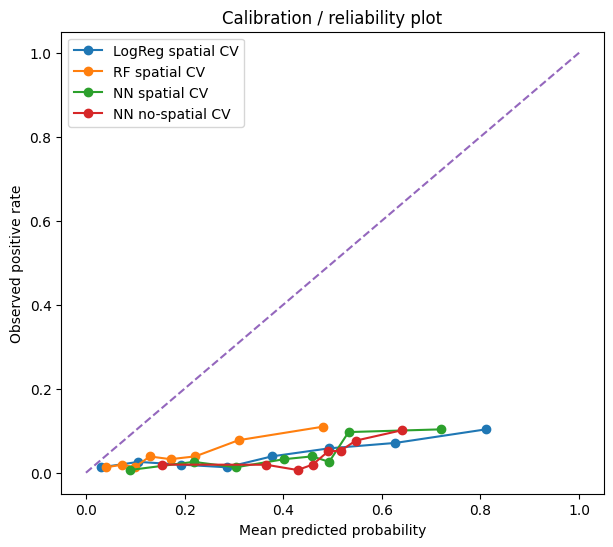

In [ ]:
plt.figure(figsize=(7, 6))

for probs, label in [
    (log_probs_spatial, "LogReg spatial CV"),
    (rf_probs_spatial, "RF spatial CV"),
    (nn_spatial_oof, "NN spatial CV"),
    (nn_nospatial_oof, "NN no-spatial CV"),
]:
    frac_pos, mean_pred = calibration_curve(y, probs, n_bins=8, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=label)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Calibration / reliability plot")
plt.legend()
plt.show()

In [ ]:
proj_df["final_risk_score"] = proj_df[best_nn_col]

final_ranked = proj_df.sort_values("final_risk_score", ascending=False)[[
    "Tree Tag Number", "Tree Genus", "Latitude", "Longitude",
    "Small tree", "Trunk Vegetation present", "Community Cluster", "Tree Island",
    "target_large_snake_tree", "final_risk_score"
]].reset_index(drop=True)

display(final_ranked.head(30))

,Tree Tag Number,Tree Genus,Latitude,Longitude,Small tree,Trunk Vegetation present,Community Cluster,Tree Island,target_large_snake_tree,final_risk_score
0,151,CASUARINA,13.561604,144.925491,0.0,1.0,0.0,1.0,0,0.876311
1,150,CASUARINA,13.561369,144.925520,0.0,1.0,0.0,1.0,1,0.872307
2,169,CASUARINA,13.561204,144.927397,0.0,1.0,0.0,1.0,0,0.872132
3,147,CASUARINA,13.561350,144.925456,0.0,1.0,0.0,1.0,0,0.871853
4,183,CASUARINA,13.561218,144.926889,0.0,1.0,0.0,1.0,0,0.871572
5,904,CASUARINA,13.561189,144.926750,0.0,1.0,0.0,1.0,0,0.870801
6,148,CASUARINA,13.561234,144.925540,0.0,1.0,0.0,1.0,1,0.869694
7,149,CASUARINA,13.561225,144.925577,0.0,1.0,0.0,1.0,0,0.869601
8,181,CASUARINA,13.561053,144.926659,0.0,1.0,0.0,1.0,1,0.867973
9,146,CASUARINA,13.561050,144.925181,0.0,1.0,0.0,1.0,0,0.866305


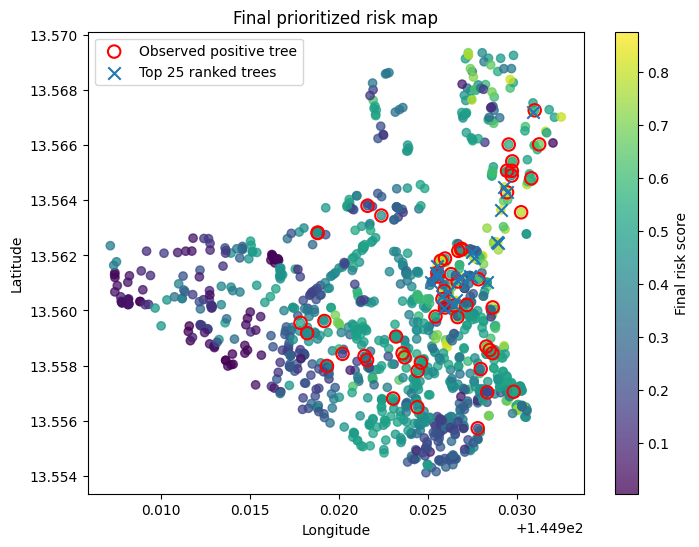

In [ ]:
top_k = 25
top_idx = final_ranked.head(top_k).index
top_tree_tags = set(final_ranked.head(top_k)["Tree Tag Number"].astype(str))

plot_df = proj_df.copy()
plot_df["Tree Tag Number"] = plot_df["Tree Tag Number"].astype(str)

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    plot_df["Longitude"],
    plot_df["Latitude"],
    c=plot_df["final_risk_score"],
    alpha=0.75
)
plt.colorbar(sc, label="Final risk score")

# Overlay observed positives
pos_df = plot_df[plot_df[TARGET_COL] == 1]
plt.scatter(
    pos_df["Longitude"], pos_df["Latitude"],
    facecolors="none", edgecolors="red", s=80, linewidths=1.5,
    label="Observed positive tree"
)

# Overlay top-K
top_df = plot_df[plot_df["Tree Tag Number"].isin(top_tree_tags)]
plt.scatter(
    top_df["Longitude"], top_df["Latitude"],
    marker="x", s=80, linewidths=1.5,
    label=f"Top {top_k} ranked trees"
)

plt.title("Final prioritized risk map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

In [ ]:
ablation_df = pd.DataFrame([
    {
        "model": "NN with spatial embeddings",
        **{k: v for k, v in nn_spatial_summary.items() if k != "model"}
    },
    {
        "model": "NN without spatial embeddings",
        **{k: v for k, v in nn_nospatial_summary.items() if k != "model"}
    }
]).sort_values("pr_auc", ascending=False)

ablation_df

,model,roc_auc,pr_auc,brier,precision@25,recall@25,precision@50,recall@50,precision@100,recall@100
0,NN with spatial embeddings,0.719479,0.122254,0.193615,0.20,0.094340,0.18,0.169811,0.12,0.226415
1,NN without spatial embeddings,0.696443,0.083673,0.220372,0.08,0.037736,0.08,0.075472,0.07,0.132075


In [ ]:
proj_df["spatial_minus_nospatial"] = proj_df["nn_spatial_oof_prob"] - proj_df["nn_nospatial_oof_prob"]

disagreement_df = proj_df.reindex(
    proj_df["spatial_minus_nospatial"].abs().sort_values(ascending=False).index
)[[
    "Tree Tag Number", "Tree Genus", "Latitude", "Longitude",
    "target_large_snake_tree", "nn_spatial_oof_prob", "nn_nospatial_oof_prob", "spatial_minus_nospatial"
]]

display(disagreement_df.head(20))

,Tree Tag Number,Tree Genus,Latitude,Longitude,target_large_snake_tree,nn_spatial_oof_prob,nn_nospatial_oof_prob,spatial_minus_nospatial
551,410,CASUARINA,13.560498,144.907746,0,0.080446,0.742939,-0.662493
554,412,CASUARINA,13.560272,144.907822,0,0.081442,0.742939,-0.661497
1001,1931,PREMNA,13.560291,144.907822,0,0.046376,0.632747,-0.586371
562,423,CASUARINA,13.559237,144.911544,0,0.005403,0.544291,-0.538888
508,359,CASUARINA,13.560903,144.907558,0,0.049022,0.586576,-0.537554
527,411,CASUARINA,13.560335,144.907775,0,0.050434,0.586576,-0.536141
528,419,CASUARINA,13.560347,144.908117,0,0.053744,0.586576,-0.532832
529,418,CASUARINA,13.560329,144.908136,0,0.054033,0.586576,-0.532543
531,413,CASUARINA,13.560212,144.908155,0,0.054055,0.586576,-0.532521
530,420,CASUARINA,13.560384,144.908144,0,0.054094,0.586576,-0.532481


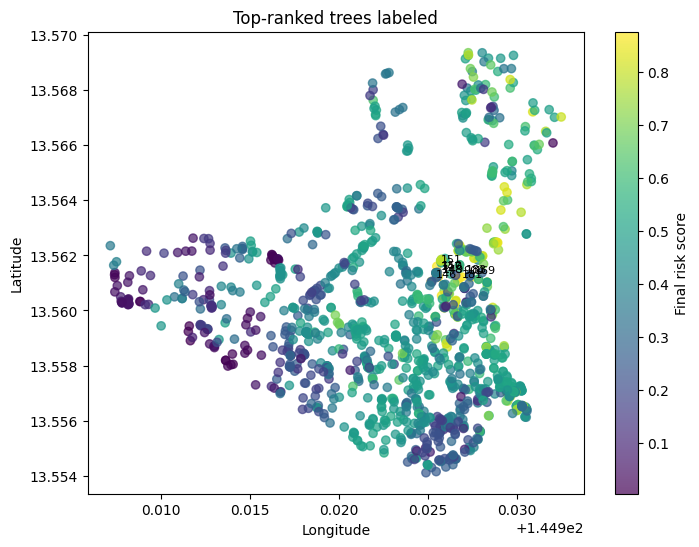

In [ ]:
top_label_k = 10
label_df = final_ranked.head(top_label_k).copy()

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    proj_df["Longitude"],
    proj_df["Latitude"],
    c=proj_df["final_risk_score"],
    alpha=0.7
)
plt.colorbar(sc, label="Final risk score")

for _, row in label_df.iterrows():
    plt.annotate(
        str(row["Tree Tag Number"]),
        (row["Longitude"], row["Latitude"]),
        fontsize=8,
        xytext=(3, 3),
        textcoords="offset points"
    )

plt.title("Top-ranked trees labeled")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()